# Single-Affinity Finite-Compliance Theory Explorer

This notebook is an executable companion to `theory_revised.py`. It is designed for two purposes:

1. **Reproduce the main objects of the revised theory**: sensing/policy, susceptibility $\chi_{h,\gamma}$, state-local action information $T_\pi$, information-response efficiency $\eta_{\rm IR}$, controlled current $J_c$, sensing information $I_{\rm sens}$, finite-time irreversibility $\Sigma$, non-storage expenditure $C_{\rm th}$, and thermodynamic efficiency $\eta_{\rm th}$.
2. **Experiment with the theory** by changing the population size, sensing budget, actuation budget, policy parameters, affinity, compliance, and initial population ensemble.

The notebook deliberately uses the same public API as the revised module rather than reimplementing formulas locally. This makes it useful as both a tutorial and a regression/inspection notebook.

### Core finite-time identities

For a state $x=n/N$,

$$
\chi_{h,\gamma}(x)=[\sigma(h)-x]\left[1-\left(1-\frac{\gamma}{N}\right)^b\right].
$$

The state-local action channel is

$$
T_\pi(n)=I(U_k;n_{k+1}\mid n_k=n),
$$

with Pinsker bound

$$
T_\pi(n)\ge \frac{2a_n(1-a_n)}{\ln 2}\,\chi_{h,\gamma}(n/N)^2,
$$

and therefore

$$
\eta_{\rm IR}(n)=
\frac{2a_n(1-a_n)\chi_{h,\gamma}(n/N)^2}
{(\ln 2)T_\pi(n)}\le 1.
$$

For an ensemble $p_k(n)$,

$$
\Delta S_{\rm sys,k}+hJ_{c,k}+I_{\rm sens,k}=\Sigma_k\ge 0,
$$

and after removing the transient storage term,

$$
C_{\rm th,k}=\Sigma_k-\Delta S_{\rm sys,k}=hJ_{c,k}+I_{\rm sens,k},
$$

so that, for target-directed operation,

$$
\eta_{\rm th,k}=\frac{hJ_{c,k}}{C_{\rm th,k}}
=\frac{hJ_{c,k}}{hJ_{c,k}+I_{\rm sens,k}}\le 1.
$$


## 0. Imports and loading `theory_revised.py`

The theory module is part of the `mas_cc` package and lives at
`src/mas_cc/games/relational_reasoning/imitation_round_feedback/theory_revised.py`.
The cell below imports it by its package path, falling back to adding the
repository's `src/` directory to `sys.path` if `mas_cc` is not installed.

In [ ]:
from pathlib import Path
import sys
import importlib
import importlib.util
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# theory_revised.py lives inside the mas_cc package, next to the game it describes:
#   src/mas_cc/games/relational_reasoning/imitation_round_feedback/theory_revised.py
MODULE_NAME = "mas_cc.games.relational_reasoning.imitation_round_feedback.theory_revised"
MODULE_RELPATH = Path("src/mas_cc/games/relational_reasoning/imitation_round_feedback/theory_revised.py")

# If mas_cc is not installed in this kernel, walk up from the working directory
# to the repository root (the first parent holding MODULE_RELPATH) and add src/.
if importlib.util.find_spec("mas_cc") is None:
    here = Path.cwd().resolve()
    repo_root = next((p for p in (here, *here.parents) if (p / MODULE_RELPATH).exists()), None)
    if repo_root is None:
        raise FileNotFoundError(f"Could not find {MODULE_RELPATH} at or above {here}")
    sys.path.insert(0, str(repo_root / "src"))

th = importlib.import_module(MODULE_NAME)

print(f"Loaded theory module from: {th.__file__}")
print("Public API:")
print(th.__all__)


## 1. Baseline parameters — edit this cell first

In [2]:
# These are intentionally easy to edit.
PARAMS = dict(
    N=24,
    q_c=12,
    b=12,
    beta=4.0,
    theta=0.5,
    h=2.0,
    gamma=0.75,
)

# Initial ensemble used in the theory report's illustrative finite-time plots.
INITIAL_TARGET_FRACTION = 0.25
HORIZON = 10

params = th.TheoryParameters(**PARAMS)
ref = th.single_affinity_reference(params)
p0 = th.binomial_ensemble(params.N, INITIAL_TARGET_FRACTION)

print(params)
print(f"p_h = sigma(h) = {params.p_h:.6f}")
print(f"Lambda_b,gamma = {params.Lambda_b_gamma:.6f}")
print(f"set point x* = {ref.set_point:.6f}")


TheoryParameters(N=24, q_c=12, b=12, beta=4.0, theta=0.5, h=2.0, gamma=0.75)
p_h = sigma(h) = 0.880797
Lambda_b,gamma = 0.316811
set point x* = 0.880797


## 2. Sensing and policy: $S(y\mid n)$, $\pi(1\mid y)$, and $a_n$

In [3]:
# Call the low-level sensing/policy functions directly.
S_example = th.sensor_law(params.N, n=params.N // 2, q_c=params.q_c)
S = th.sensor_kernel(params.N, params.q_c)
pi1 = th.policy_advocacy_vector(params.q_c, params.beta, params.theta)
a_curve = th.advocacy_probability_curve(params)

print("Example sensor law at n=N/2 sums to:", S_example.sum())
print("Sensor kernel shape:", S.shape)
print("Policy vector shape:", pi1.shape)
print("Advocacy curve shape:", a_curve.shape)


Example sensor law at n=N/2 sums to: 1.0
Sensor kernel shape: (25, 13)
Policy vector shape: (13,)
Advocacy curve shape: (25,)


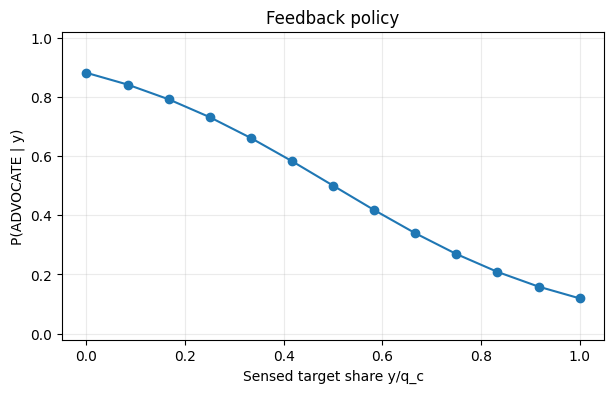

In [4]:
plt.figure(figsize=(7, 4))
plt.plot(np.arange(params.q_c + 1) / params.q_c, pi1, marker="o")
plt.xlabel("Sensed target share y/q_c")
plt.ylabel("P(ADVOCATE | y)")
plt.title("Feedback policy")
plt.ylim(-0.02, 1.02)
plt.grid(alpha=0.25)
plt.show()


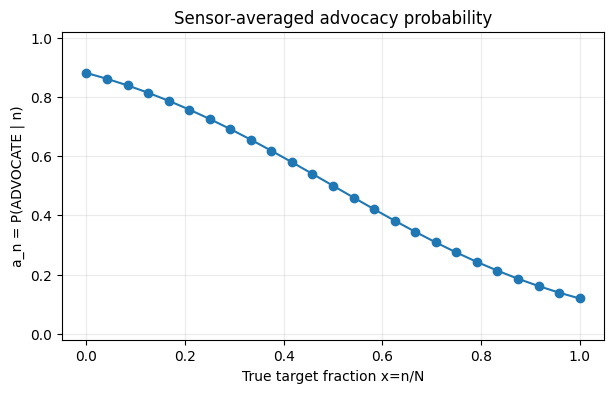

In [5]:
plt.figure(figsize=(7, 4))
plt.plot(ref.shares, ref.advocacy, marker="o")
plt.xlabel("True target fraction x=n/N")
plt.ylabel("a_n = P(ADVOCATE | n)")
plt.title("Sensor-averaged advocacy probability")
plt.ylim(-0.02, 1.02)
plt.grid(alpha=0.25)
plt.show()


## 3. Controlled microscopic kernel and action-conditioned kernels

In [6]:
K = th.controlled_kernel(params)
Q0 = th.noop_kernel(params.N)
Q1 = th.advocate_kernel(K, params.b)

print("K row sums:", np.max(np.abs(K.sum(axis=1) - 1.0)))
print("Q0 row sums:", np.max(np.abs(Q0.sum(axis=1) - 1.0)))
print("Q1 row sums:", np.max(np.abs(Q1.sum(axis=1) - 1.0)))
print("Microscopic reversibility check: min forward/reverse support away from boundaries")
print("  K[n,n+1] > 0 for finite h,gamma:", np.all(K[:-1, 1:].diagonal() > 0) if params.gamma > 0 else "gamma=0")
print("  K[n,n-1] > 0 for finite h,gamma:", np.all(K[1:, :-1].diagonal() > 0) if params.gamma > 0 else "gamma=0")


K row sums: 1.1102230246251565e-16
Q0 row sums: 0.0
Q1 row sums: 5.551115123125783e-16
Microscopic reversibility check: min forward/reverse support away from boundaries
  K[n,n+1] > 0 for finite h,gamma: True
  K[n,n-1] > 0 for finite h,gamma: True


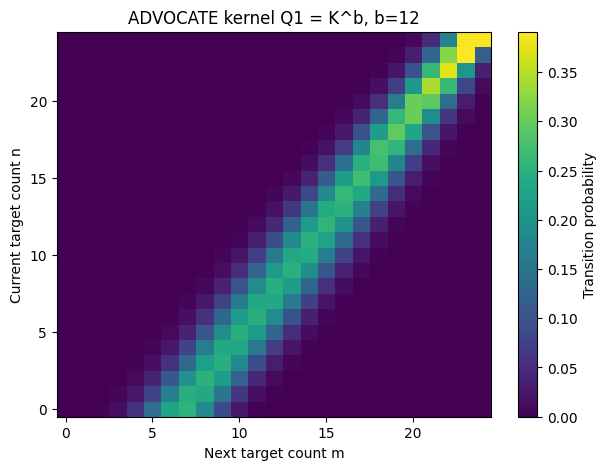

In [7]:
plt.figure(figsize=(7, 5))
plt.imshow(Q1, origin="lower", aspect="auto")
plt.xlabel("Next target count m")
plt.ylabel("Current target count n")
plt.title(f"ADVOCATE kernel Q1 = K^b, b={params.b}")
plt.colorbar(label="Transition probability")
plt.show()


## 4. Exact susceptibility $\chi_{h,\gamma}(x)$

In [8]:
# Exercise both scalar and curve APIs.
chi_scalar = th.susceptibility(0.5, params)
chi_curve = th.susceptibility_curve(params)
chi_kernel = th.kernel_mean_response(ref.Q0, ref.Q1, params.N)

print(f"chi(x=0.5) = {chi_scalar:.6f}")
print("Max closed-form vs kernel discrepancy:", np.max(np.abs(chi_curve - chi_kernel)))


chi(x=0.5) = 0.120641
Max closed-form vs kernel discrepancy: 5.793976409762536e-16


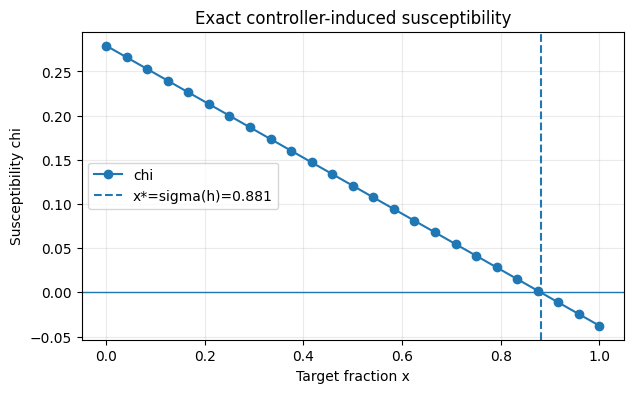

In [9]:
plt.figure(figsize=(7, 4))
plt.plot(ref.shares, ref.chi, marker="o", label="chi")
plt.axhline(0.0, linewidth=1)
plt.axvline(ref.set_point, linestyle="--", label=f"x*=sigma(h)={ref.set_point:.3f}")
plt.xlabel("Target fraction x")
plt.ylabel("Susceptibility chi")
plt.title("Exact controller-induced susceptibility")
plt.legend()
plt.grid(alpha=0.25)
plt.show()


### 4.1 Experiment with compliance $\gamma$

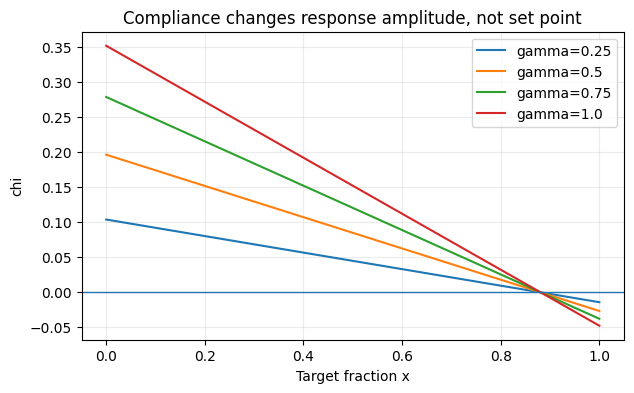

In [10]:
gamma_values = [0.25, 0.5, 0.75, 1.0]
plt.figure(figsize=(7, 4))
for gamma in gamma_values:
    p = th.TheoryParameters(**{**PARAMS, "gamma": gamma})
    r = th.single_affinity_reference(p)
    plt.plot(r.shares, r.chi, label=f"gamma={gamma}")
plt.axhline(0.0, linewidth=1)
plt.xlabel("Target fraction x")
plt.ylabel("chi")
plt.title("Compliance changes response amplitude, not set point")
plt.legend()
plt.grid(alpha=0.25)
plt.show()


## 5. State-local action information $T_\pi(n)$ and the Pinsker bound

In [11]:
T_direct = th.local_action_information(ref.Q0, ref.Q1, ref.advocacy)
T_alias = th.local_transfer_entropy(ref.Q0, ref.Q1, ref.advocacy)
pinsker = th.information_response_lower_bound(ref.advocacy, ref.chi)
entropy_ceiling = ref.entropy_ceiling()

print("T_pi alias agrees:", np.max(np.abs(T_direct - T_alias)))
print("Minimum T_pi - Pinsker bound:", np.min(ref.T_pi - pinsker))
print("Minimum entropy ceiling - T_pi:", np.min(entropy_ceiling - ref.T_pi))


T_pi alias agrees: 0.0
Minimum T_pi - Pinsker bound: 0.26199949038592696
Minimum entropy ceiling - T_pi: 0.00012451460081241983


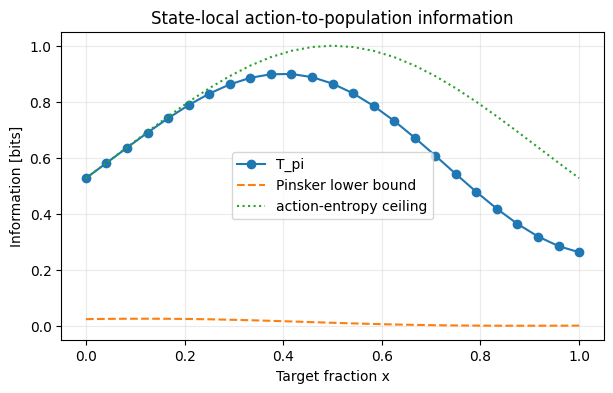

In [12]:
plt.figure(figsize=(7, 4))
plt.plot(ref.shares, ref.T_pi, marker="o", label="T_pi")
plt.plot(ref.shares, ref.pinsker_bound, linestyle="--", label="Pinsker lower bound")
plt.plot(ref.shares, ref.entropy_ceiling(), linestyle=":", label="action-entropy ceiling")
plt.xlabel("Target fraction x")
plt.ylabel("Information [bits]")
plt.title("State-local action-to-population information")
plt.legend()
plt.grid(alpha=0.25)
plt.show()


## 6. Information-response efficiency $\eta_{m IR}$

In [13]:
eta_ir_direct = th.information_response_efficiency(ref.advocacy, ref.chi, ref.T_pi)
print("Max |eta_IR direct - reference|:", np.nanmax(np.abs(eta_ir_direct - ref.eta_IR)))
print("eta_IR range:", np.nanmin(ref.eta_IR), np.nanmax(ref.eta_IR))


Max |eta_IR direct - reference|: 0.0
eta_IR range: 4.050884777980641e-06 0.04476709274083087


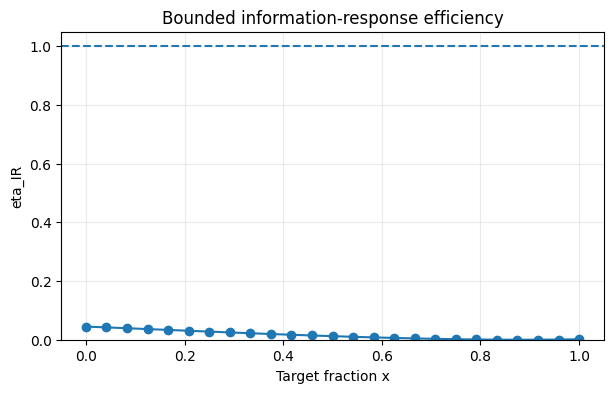

In [14]:
plt.figure(figsize=(7, 4))
plt.plot(ref.shares, ref.eta_IR, marker="o")
plt.axhline(1.0, linestyle="--")
plt.xlabel("Target fraction x")
plt.ylabel("eta_IR")
plt.title("Bounded information-response efficiency")
plt.ylim(0, 1.05)
plt.grid(alpha=0.25)
plt.show()


## 7. One-cycle finite-time thermodynamics

In [15]:
# Exercise the ensemble-level functions directly.
S0 = th.system_entropy(p0, params.N)
I_sens_direct, pY_direct = th.sensing_information_nats(p0, ref.S)
J_direct = th.mean_controlled_current(p0, ref.advocacy, ref.chi, params.N)
eta_th_direct, Cth_direct, bounded_direct = th.thermodynamic_efficiency(
    h=params.h, J_c=J_direct, I_sens_nats=I_sens_direct
)

cycle = ref.one_cycle(p0, check_kl=True)

summary = pd.Series({
    "J_c": cycle.J_c,
    "h J_c [nats]": cycle.directed_current_nats,
    "I_sens [nats]": cycle.I_sens_nats,
    "Delta S_sys [nats]": cycle.delta_S_sys_nats,
    "Sigma [nats]": cycle.Sigma_nats,
    "Sigma direct KL [nats]": cycle.Sigma_direct_KL_nats,
    "C_th [nats]": cycle.C_th_nats,
    "eta_th": cycle.eta_th,
    "identity residual": cycle.identity_residual_nats,
    "second law satisfied": cycle.second_law_satisfied,
    "bounded eta_th interpretation": cycle.eta_th_has_bounded_interpretation,
})
display(summary.to_frame("value"))

print("Direct helper vs assembled J_c:", abs(J_direct - cycle.J_c))
print("Direct helper vs assembled I_sens:", abs(I_sens_direct - cycle.I_sens_nats))
print("Direct helper vs assembled eta_th:", abs(eta_th_direct - cycle.eta_th))


,value
J_c,3.504305
h J_c [nats],7.008611
I_sens [nats],0.355425
Delta S_sys [nats],2.565048
Sigma [nats],9.929084
Sigma direct KL [nats],9.929084
C_th [nats],7.364036
eta_th,0.951735
identity residual,-0.0
second law satisfied,True


Direct helper vs assembled J_c: 0.0
Direct helper vs assembled I_sens: 0.0
Direct helper vs assembled eta_th: 0.0


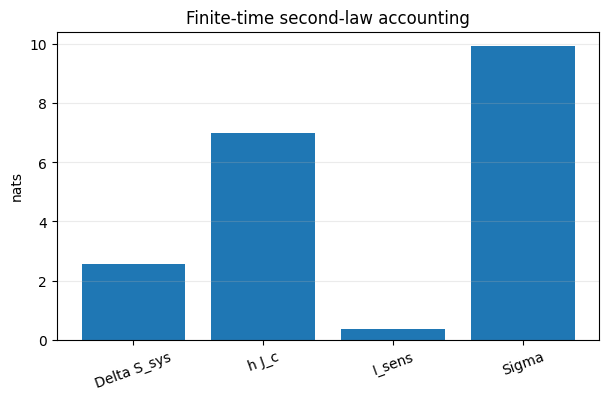

In [16]:
labels = ["Delta S_sys", "h J_c", "I_sens", "Sigma"]
values = [cycle.delta_S_sys_nats, cycle.directed_current_nats, cycle.I_sens_nats, cycle.Sigma_nats]
plt.figure(figsize=(7, 4))
plt.bar(labels, values)
plt.ylabel("nats")
plt.title("Finite-time second-law accounting")
plt.xticks(rotation=20)
plt.grid(axis="y", alpha=0.25)
plt.show()


## 8. Propagation and finite-horizon thermodynamics

In [17]:
p1 = ref.propagate(p0)
history_pre = ref.self_occupancy(p0, rounds=HORIZON)
horizon = th.finite_horizon_thermodynamics(ref, p0, rounds=HORIZON, check_kl=True)

print("p1 normalization:", p1.sum())
print("self_occupancy shape (pre-cycle states):", history_pre.shape)
print("finite-horizon p_history shape (includes final state):", horizon.p_history.shape)

horizon_summary = pd.Series({
    "total J_c": horizon.total_J_c,
    "total h J_c [nats]": horizon.directed_current_nats,
    "total I_sens [nats]": horizon.total_I_sens_nats,
    "total Delta S_sys [nats]": horizon.total_delta_S_sys_nats,
    "total Sigma [nats]": horizon.total_Sigma_nats,
    "total C_th [nats]": horizon.total_C_th_nats,
    "eta_th": horizon.eta_th,
    "identity residual": horizon.identity_residual_nats,
})
display(horizon_summary.to_frame("value"))


p1 normalization: 1.0
self_occupancy shape (pre-cycle states): (10, 25)
finite-horizon p_history shape (includes final state): (11, 25)


,value
total J_c,1.210619e+01
total h J_c [nats],2.421239e+01
total I_sens [nats],3.951135e+00
total Delta S_sys [nats],-1.180049e-01
total Sigma [nats],2.804552e+01
total C_th [nats],2.816352e+01
eta_th,8.597074e-01
identity residual,-3.552714e-15


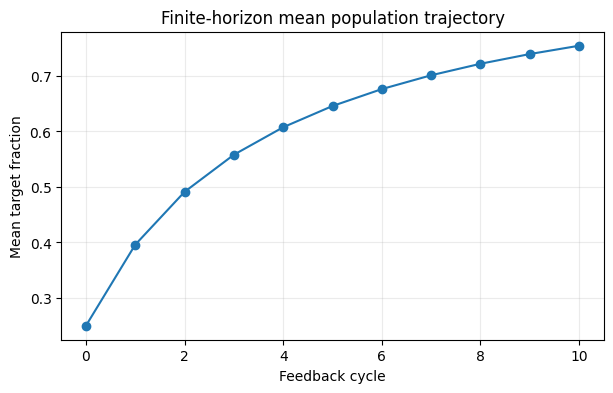

In [18]:
states = np.arange(params.N + 1)
means = horizon.p_history @ states / params.N
plt.figure(figsize=(7, 4))
plt.plot(np.arange(HORIZON + 1), means, marker="o")
plt.xlabel("Feedback cycle")
plt.ylabel("Mean target fraction")
plt.title("Finite-horizon mean population trajectory")
plt.grid(alpha=0.25)
plt.show()


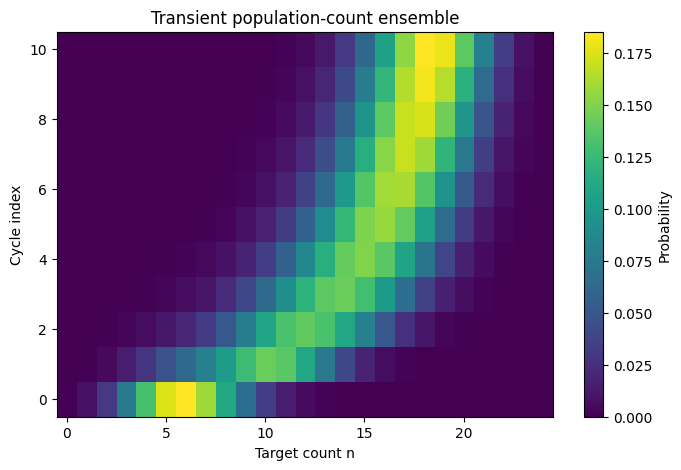

In [19]:
plt.figure(figsize=(8, 5))
plt.imshow(horizon.p_history, origin="lower", aspect="auto")
plt.xlabel("Target count n")
plt.ylabel("Cycle index")
plt.title("Transient population-count ensemble")
plt.colorbar(label="Probability")
plt.show()


## 9. Terminal-current moments

In [20]:
moments = th.finite_horizon_current_moments(
    ref.closed_loop_kernel,
    p0,
    rounds=HORIZON,
)
print(moments)


{'mean': 12.106192787742364, 'second_moment': 154.8879857992732, 'variance': 8.32808198528798}


## 10. Microscopic calibration of $h$ and $\gamma$

In [21]:
# Paper/example counts from the state-matched susceptibility experiment.
cal_counts = th.calibrate_affinity_compliance_from_counts(
    plus_transitions=208,
    plus_eligible=572,
    minus_transitions=4,
    minus_eligible=508,
)
cal_probs = th.calibrate_affinity_compliance(cal_counts.p_plus, cal_counts.p_minus)

print(cal_counts)
print(f"forward/reverse odds = exp(h_eff) = {cal_counts.forward_reverse_odds:.3f}")
print("Probability-based calibration agrees:", cal_probs)

calibrated_params = th.TheoryParameters(**{
    **PARAMS,
    "h": cal_counts.h_eff,
    "gamma": cal_counts.gamma_eff,
})
calibrated_ref = th.single_affinity_reference(calibrated_params)
print("Calibrated set point:", calibrated_ref.set_point)


AffinityComplianceCalibration(p_plus=0.36363636363636365, p_minus=0.007874015748031496, h_eff=3.8325861747801113, gamma_eff=0.37151037938439513)
forward/reverse odds = exp(h_eff) = 46.182
Probability-based calibration agrees: AffinityComplianceCalibration(p_plus=0.36363636363636365, p_minus=0.007874015748031496, h_eff=3.8325861747801113, gamma_eff=0.37151037938439513)
Calibrated set point: 0.9788053949903661


## 11. Resource sweep: sensing $q_c$ versus actuation $b$

In [22]:
def resource_sweep(
    *,
    N=24,
    q_c_values=(6, 12, 18),
    b_values=(1, 3, 6, 9, 12, 15, 18, 21, 24),
    beta=4.0,
    theta=0.5,
    h=2.0,
    gamma=0.75,
    x0=0.25,
):
    rows = []
    p0_local = th.binomial_ensemble(N, x0)
    for q_c in q_c_values:
        for b in b_values:
            p = th.TheoryParameters(N=N, q_c=q_c, b=b, beta=beta, theta=theta, h=h, gamma=gamma)
            r = th.single_affinity_reference(p)
            c = r.one_cycle(p0_local)
            # Occupancy-averaged state-local information quantities.
            T_occ = r.occupancy_weighted_T_pi(p0_local)
            eta_ir_occ = r.occupancy_average(np.nan_to_num(r.eta_IR, nan=0.0), p0_local)
            rows.append({
                "q_c": q_c,
                "b": b,
                "J_c": c.J_c,
                "I_sens_nats": c.I_sens_nats,
                "Sigma_nats": c.Sigma_nats,
                "C_th_nats": c.C_th_nats,
                "eta_th": c.eta_th,
                "T_pi_occ_bits": T_occ,
                "eta_IR_occ": eta_ir_occ,
            })
    return pd.DataFrame(rows)

sweep = resource_sweep()
display(sweep.head(12))


,q_c,b,J_c,I_sens_nats,Sigma_nats,C_th_nats,eta_th,T_pi_occ_bits,eta_IR_occ
0,6,1,0.341706,0.146329,1.191565,0.829742,0.823645,0.230347,0.000961
1,6,3,0.993418,0.146329,3.116599,2.133165,0.931403,0.521082,0.003581
2,6,6,1.896583,0.146329,5.646229,3.939496,0.962856,0.716177,0.009528
3,6,9,2.717695,0.146329,7.798732,5.581720,0.973784,0.791691,0.017794
4,6,12,3.464208,0.146329,9.620385,7.074746,0.979317,0.822632,0.027947
5,6,15,4.142900,0.146329,11.156321,8.432130,0.982646,0.835997,0.039443
6,6,18,4.759932,0.146329,12.449494,9.666194,0.984862,0.842082,0.051780
7,6,21,5.320907,0.146329,13.538318,10.788143,0.986436,0.844999,0.064545
8,6,24,5.830916,0.146329,14.455765,11.808161,0.987608,0.846466,0.077422
9,12,1,0.345662,0.355425,1.412609,1.046749,0.660448,0.225144,0.000964


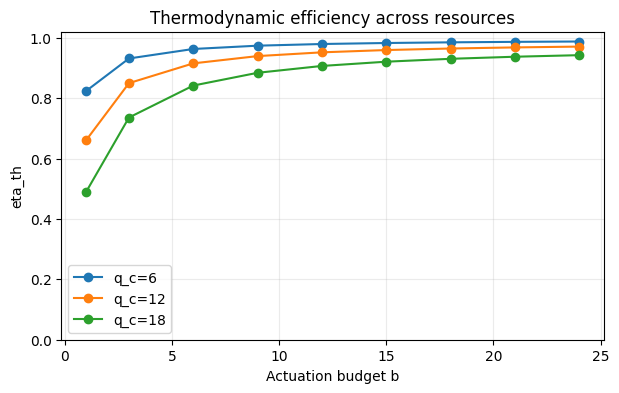

In [23]:
plt.figure(figsize=(7, 4))
for q_c, group in sweep.groupby("q_c"):
    plt.plot(group["b"], group["eta_th"], marker="o", label=f"q_c={q_c}")
plt.xlabel("Actuation budget b")
plt.ylabel("eta_th")
plt.title("Thermodynamic efficiency across resources")
plt.ylim(0, 1.02)
plt.legend()
plt.grid(alpha=0.25)
plt.show()


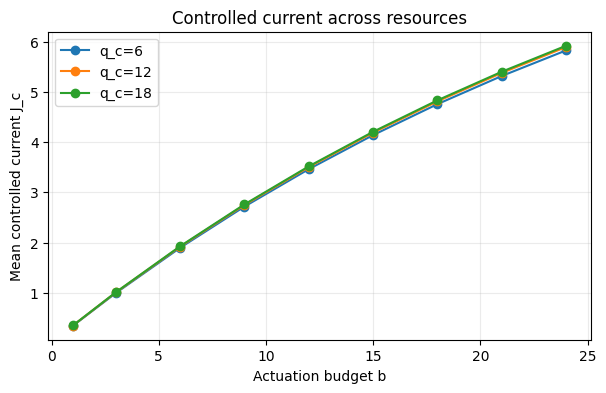

In [24]:
plt.figure(figsize=(7, 4))
for q_c, group in sweep.groupby("q_c"):
    plt.plot(group["b"], group["J_c"], marker="o", label=f"q_c={q_c}")
plt.xlabel("Actuation budget b")
plt.ylabel("Mean controlled current J_c")
plt.title("Controlled current across resources")
plt.legend()
plt.grid(alpha=0.25)
plt.show()


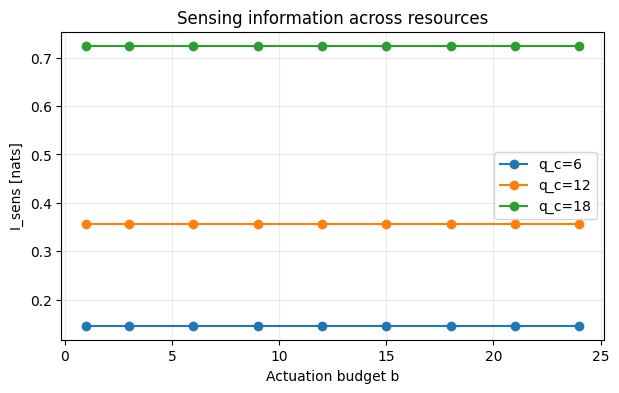

In [25]:
plt.figure(figsize=(7, 4))
for q_c, group in sweep.groupby("q_c"):
    plt.plot(group["b"], group["I_sens_nats"], marker="o", label=f"q_c={q_c}")
plt.xlabel("Actuation budget b")
plt.ylabel("I_sens [nats]")
plt.title("Sensing information across resources")
plt.legend()
plt.grid(alpha=0.25)
plt.show()


## 12. Parameter sweep helpers for $h$, $\gamma$, $eta$, and $	heta$

In [26]:
def sweep_parameter(name, values, base=PARAMS, x0=0.25):
    rows = []
    for value in values:
        p_dict = dict(base)
        p_dict[name] = value
        p = th.TheoryParameters(**p_dict)
        r = th.single_affinity_reference(p)
        p0_local = th.binomial_ensemble(p.N, x0)
        c = r.one_cycle(p0_local)
        rows.append({
            name: value,
            "set_point": r.set_point,
            "Lambda": r.Lambda_b_gamma,
            "J_c": c.J_c,
            "I_sens_nats": c.I_sens_nats,
            "eta_th": c.eta_th,
            "T_pi_occ_bits": r.occupancy_weighted_T_pi(p0_local),
            "eta_IR_occ": r.occupancy_average(np.nan_to_num(r.eta_IR, nan=0.0), p0_local),
        })
    return pd.DataFrame(rows)

h_sweep = sweep_parameter("h", [0.5, 1.0, 2.0, 4.0])
gamma_sweep = sweep_parameter("gamma", [0.25, 0.5, 0.75, 1.0])
beta_sweep = sweep_parameter("beta", [1.0, 2.0, 4.0, 8.0])
theta_sweep = sweep_parameter("theta", [0.25, 0.4, 0.5, 0.75])

display(h_sweep)


,h,set_point,Lambda,J_c,I_sens_nats,eta_th,T_pi_occ_bits,eta_IR_occ
0,0.5,0.622459,0.316811,2.088405,0.355425,0.746057,0.647242,0.012104
1,1.0,0.731059,0.316811,2.683617,0.355425,0.883047,0.731771,0.017814
2,2.0,0.880797,0.316811,3.504305,0.355425,0.951735,0.810945,0.027802
3,4.0,0.982014,0.316811,4.059055,0.355425,0.978578,0.833663,0.036516


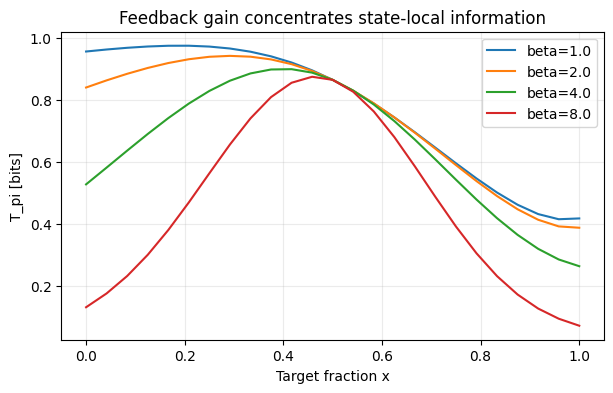

In [27]:
plt.figure(figsize=(7, 4))
for beta in [1.0, 2.0, 4.0, 8.0]:
    p = th.TheoryParameters(**{**PARAMS, "beta": beta})
    r = th.single_affinity_reference(p)
    plt.plot(r.shares, r.T_pi, label=f"beta={beta}")
plt.xlabel("Target fraction x")
plt.ylabel("T_pi [bits]")
plt.title("Feedback gain concentrates state-local information")
plt.legend()
plt.grid(alpha=0.25)
plt.show()


## 13. One function for quick experiments

,value
p_h,0.880797
Lambda_b_gamma,0.316811
J_c,3.504305
hJ_c_nats,7.008611
I_sens_nats,0.355425
delta_S_sys_nats,2.565048
Sigma_nats,9.929084
C_th_nats,7.364036
eta_th,0.951735
T_pi_occ_bits,0.810945


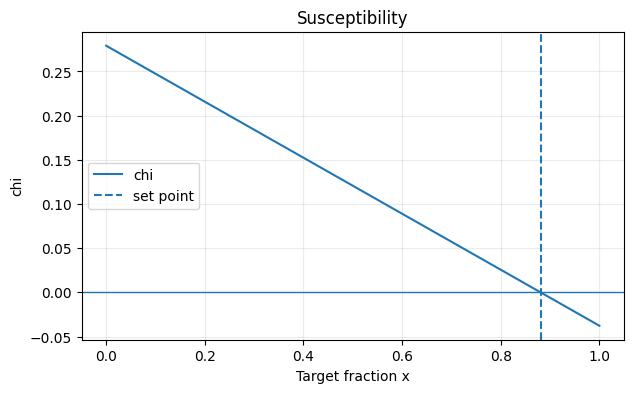

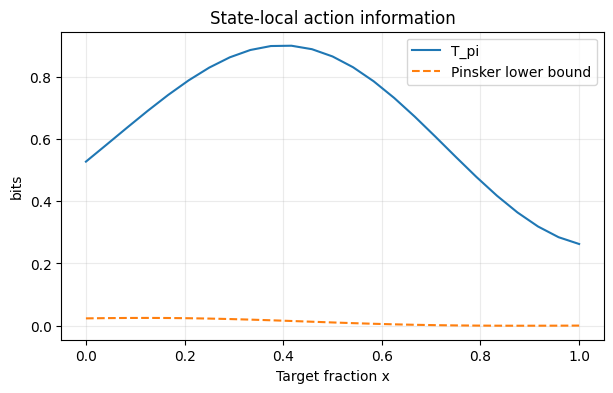

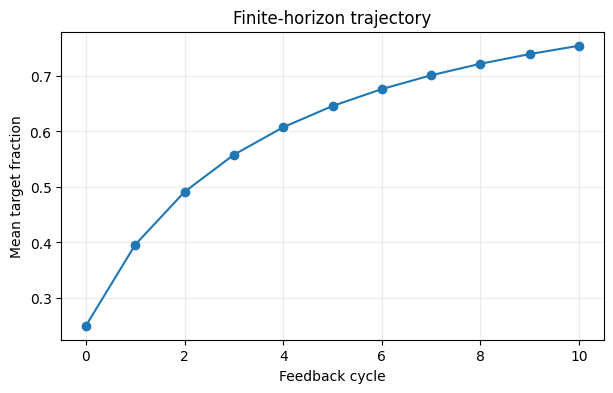

In [28]:
def run_experiment(
    *,
    N=24,
    q_c=12,
    b=12,
    beta=4.0,
    theta=0.5,
    h=2.0,
    gamma=0.75,
    x0=0.25,
    rounds=10,
    make_plots=True,
):
    # Convenience wrapper for interactive exploration.
    # Example: result = run_experiment(q_c=18, b=6, gamma=0.4, h=3.0)
    p = th.TheoryParameters(N=N, q_c=q_c, b=b, beta=beta, theta=theta, h=h, gamma=gamma)
    r = th.single_affinity_reference(p)
    initial = th.binomial_ensemble(N, x0)
    cycle = r.one_cycle(initial)
    horizon = th.finite_horizon_thermodynamics(r, initial, rounds=rounds)

    result = {
        "parameters": p,
        "reference": r,
        "initial": initial,
        "cycle": cycle,
        "horizon": horizon,
        "summary": pd.Series({
            "p_h": p.p_h,
            "Lambda_b_gamma": p.Lambda_b_gamma,
            "J_c": cycle.J_c,
            "hJ_c_nats": cycle.directed_current_nats,
            "I_sens_nats": cycle.I_sens_nats,
            "delta_S_sys_nats": cycle.delta_S_sys_nats,
            "Sigma_nats": cycle.Sigma_nats,
            "C_th_nats": cycle.C_th_nats,
            "eta_th": cycle.eta_th,
            "T_pi_occ_bits": r.occupancy_weighted_T_pi(initial),
            "eta_IR_occ": r.occupancy_average(np.nan_to_num(r.eta_IR, nan=0.0), initial),
        })
    }

    display(result["summary"].to_frame("value"))

    if make_plots:
        plt.figure(figsize=(7, 4))
        plt.plot(r.shares, r.chi, label="chi")
        plt.axhline(0.0, linewidth=1)
        plt.axvline(r.set_point, linestyle="--", label="set point")
        plt.xlabel("Target fraction x")
        plt.ylabel("chi")
        plt.title("Susceptibility")
        plt.legend()
        plt.grid(alpha=0.25)
        plt.show()

        plt.figure(figsize=(7, 4))
        plt.plot(r.shares, r.T_pi, label="T_pi")
        plt.plot(r.shares, r.pinsker_bound, linestyle="--", label="Pinsker lower bound")
        plt.xlabel("Target fraction x")
        plt.ylabel("bits")
        plt.title("State-local action information")
        plt.legend()
        plt.grid(alpha=0.25)
        plt.show()

        means = horizon.p_history @ np.arange(N + 1) / N
        plt.figure(figsize=(7, 4))
        plt.plot(np.arange(rounds + 1), means, marker="o")
        plt.xlabel("Feedback cycle")
        plt.ylabel("Mean target fraction")
        plt.title("Finite-horizon trajectory")
        plt.grid(alpha=0.25)
        plt.show()

    return result

# Example:
result = run_experiment(N=24, q_c=12, b=12, beta=4, theta=0.5, h=2, gamma=0.75, x0=0.25, rounds=10)


## 14. Reading parameters from a runtime record

In [29]:
example_record = {
    "N": 24,
    "social_group_size": 1,
    "sensor_sample_size": 12,
    "intervention_budget": 18,
    "controller_beta": 4.0,
    "controller_threshold": 0.5,
}

parsed = th.theory_parameters_from_record(
    example_record,
    h=cal_counts.h_eff,
    gamma=cal_counts.gamma_eff,
)
print(parsed)


TheoryParameters(N=24, q_c=12, b=18, beta=4.0, theta=0.5, h=3.8325861747801113, gamma=0.37151037938439513)


## 15. Public-API coverage / sanity checks

In [30]:
# This cell intentionally touches every public function exported by theory_revised.py.
# It is useful after editing the module because a failure here immediately identifies API drift.

_api_results = {}
_api_results["logistic"] = th.logistic(0.0)
_api_results["binary_entropy_bits"] = th.binary_entropy_bits(0.5)
_api_results["sensor_law"] = th.sensor_law(params.N, 6, params.q_c).sum()
_api_results["sensor_kernel"] = th.sensor_kernel(params.N, params.q_c).shape
_api_results["policy_advocacy_vector"] = th.policy_advocacy_vector(params.q_c, params.beta, params.theta).shape
_api_results["advocacy_probability_curve"] = th.advocacy_probability_curve(params).shape
_api_results["controlled_kernel"] = th.controlled_kernel(params).shape
_api_results["noop_kernel"] = th.noop_kernel(params.N).shape
_api_results["advocate_kernel"] = th.advocate_kernel(ref.K, params.b).shape
_api_results["susceptibility"] = th.susceptibility(0.4, params)
_api_results["susceptibility_curve"] = th.susceptibility_curve(params).shape
_api_results["kernel_mean_response"] = th.kernel_mean_response(ref.Q0, ref.Q1, params.N).shape
_api_results["local_action_information"] = th.local_action_information(ref.Q0, ref.Q1, ref.advocacy).shape
_api_results["local_transfer_entropy"] = th.local_transfer_entropy(ref.Q0, ref.Q1, ref.advocacy).shape
_api_results["information_response_lower_bound"] = th.information_response_lower_bound(ref.advocacy, ref.chi).shape
_api_results["information_response_efficiency"] = th.information_response_efficiency(ref.advocacy, ref.chi, ref.T_pi).shape
_api_results["binomial_ensemble"] = th.binomial_ensemble(params.N, 0.25).sum()
_api_results["system_entropy"] = th.system_entropy(p0, params.N)
_api_results["sensing_information_nats"] = th.sensing_information_nats(p0, ref.S)[0]
_api_results["mean_controlled_current"] = th.mean_controlled_current(p0, ref.advocacy, ref.chi, params.N)
_api_results["thermodynamic_efficiency"] = th.thermodynamic_efficiency(h=params.h, J_c=cycle.J_c, I_sens_nats=cycle.I_sens_nats)
_api_results["single_affinity_reference"] = type(th.single_affinity_reference(params)).__name__
_api_results["finite_horizon_thermodynamics"] = th.finite_horizon_thermodynamics(ref, p0, 2, check_kl=False).total_Sigma_nats
_api_results["finite_horizon_current_moments"] = th.finite_horizon_current_moments(ref.closed_loop_kernel, p0, 2)
_api_results["calibrate_affinity_compliance"] = th.calibrate_affinity_compliance(0.2, 0.01)
_api_results["calibrate_affinity_compliance_from_counts"] = th.calibrate_affinity_compliance_from_counts(plus_transitions=20, plus_eligible=100, minus_transitions=1, minus_eligible=100)
_api_results["theory_parameters_from_record"] = th.theory_parameters_from_record(example_record, h=2.0, gamma=0.75)

coverage = pd.DataFrame({"result": {k: str(v) for k, v in _api_results.items()}})
display(coverage)

missing = sorted(set(th.__all__) - set(_api_results) - {
    "TheoryParameters", "SingleAffinityReference", "CycleThermodynamics",
    "FiniteHorizonThermodynamics", "AffinityComplianceCalibration"
})
print("Uncovered exported functions:", missing)
assert not missing
assert cycle.second_law_satisfied
assert abs(cycle.identity_residual_nats) < 1e-9
assert np.nanmax(ref.eta_IR) <= 1.0 + 1e-10
if cycle.eta_th_has_bounded_interpretation:
    assert 0.0 <= cycle.eta_th <= 1.0 + 1e-10
print("All sanity checks passed.")


,result
logistic,0.5
binary_entropy_bits,1.0
sensor_law,1.0
sensor_kernel,"(25, 13)"
policy_advocacy_vector,"(13,)"
advocacy_probability_curve,"(25,)"
controlled_kernel,"(25, 25)"
noop_kernel,"(25, 25)"
advocate_kernel,"(25, 25)"
susceptibility,0.15232201409519397


Uncovered exported functions: []
All sanity checks passed.


## Suggested experiments

A useful way to use the notebook is to change **one physical role at a time**:

- **Sensing:** vary `q_c` while holding `b,h,gamma,beta,theta` fixed. Inspect $I_{\rm sens}$, $a_n$, and $\eta_{\rm th}$.
- **Actuation:** vary `b`. Inspect $\Lambda_{b,\gamma}$, $\chi$, $J_c$, $T_\pi$, $\eta_{\rm IR}$, and $\eta_{\rm th}$.
- **Directional affinity:** vary `h`. The set point $x^*=\sigma(h)$ moves and the forward/reverse asymmetry changes.
- **Kinetic compliance:** vary `gamma`. The set point stays fixed while the response amplitude changes.
- **Feedback gain:** vary `beta`. The action-information band should concentrate near the policy switching region as the policy becomes sharper.
- **Feedback threshold:** vary `theta`. The switching region moves through state space.
- **Initial ensemble:** vary `INITIAL_TARGET_FRACTION`. State-local objects such as $\chi(n)$ and $T_\pi(n)$ do not change, but ensemble quantities such as $J_c$, $I_{\rm sens}$, $\Delta S_{\rm sys}$, $\Sigma$, and $\eta_{\rm th}$ do.

The distinction between **state-local theory** and **ensemble-dependent thermodynamics** is important: the first describes channel geometry at a fixed state, while the second depends on which states the population actually occupies.
